In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import os

IMAGE_DIR = "../data/raw/flickr30k_images/flickr30k_images"
CAPTION_DIR = "../data/raw/flickr30k_images/results.csv"

df = pd.read_csv(CAPTION_DIR, sep = '|')
df.columns = df.columns.str.strip()

print(df.shape)
df.head(10)

(158915, 3)


,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .
5,10002456.jpg,0,Several men in hard hats are operating a gian...
6,10002456.jpg,1,Workers look down from up above on a piece of...
7,10002456.jpg,2,Two men working on a machine wearing hard hats .
8,10002456.jpg,3,Four men on top of a tall structure .
9,10002456.jpg,4,Three men on a large rig .


In [3]:
print(f"unique images: {df['image_name'].nunique()}")
print(f"caption len: {len(df)}")
print(f"image/caption:\n{df.groupby('image_name').size().value_counts()}")

unique images: 31783
caption len: 158915
image/caption:
5    31783
Name: count, dtype: int64


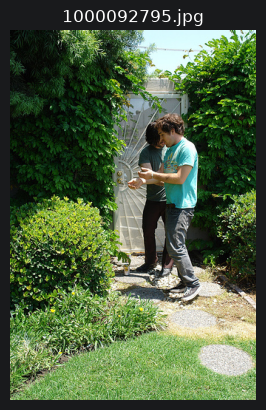

0)  Two young guys with shaggy hair look at their hands while hanging out in the yard .
1)  Two young , White males are outside near many bushes .
2)  Two men in green shirts are standing in a yard .
3)  A man in a blue shirt standing in a garden .
4)  Two friends enjoy time spent together .


In [4]:
sample_img = df['image_name'].iloc[0]
captions = df[df['image_name'] == sample_img]['comment'].tolist()

img = Image.open(os.path.join(IMAGE_DIR, sample_img))
plt.imshow(img)
plt.axis('off')
plt.title(sample_img)
plt.show()

for i, cap in enumerate(captions):
    print(f"{i}) {cap}")

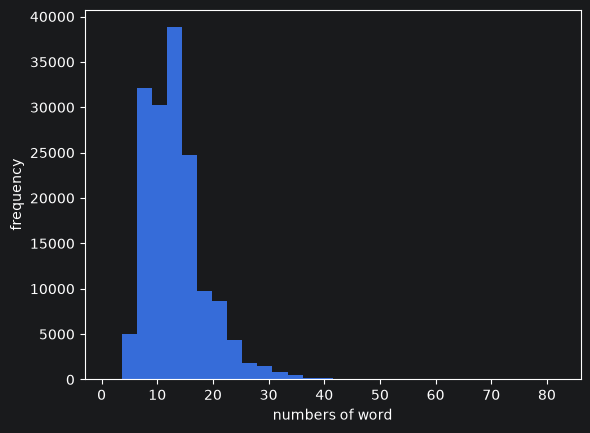

mean length: 13.389340213321587
min length: 1
max length: 82
percentile 95%: 23.0


In [5]:
caption_length = df['comment'].apply(lambda x: len(str(x).split()))
plt.hist(caption_length, bins = 30)
plt.xlabel('numbers of word')
plt.ylabel('frequency')
plt.show()

print(f"mean length: {caption_length.mean()}")
print(f"min length: {caption_length.min()}")
print(f"max length: {caption_length.max()}")
print(f"percentile 95%: {caption_length.quantile(0.95)}")